<a href="https://colab.research.google.com/github/naga-sravani-g/ApexPlanet_DA-Task-3/blob/main/Deep_Dive_Analysis_%26_Interactive_Dashboarding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [ ]:
from google.colab import files
import io

print("Please upload the 'amazon_sales_dataset.csv' file.")
uploaded = files.upload()

# Assuming the user uploads 'sample-superstore.csv'
for fn in uploaded.keys():
    print('User uploaded file "{name}" with length {length} bytes'.format(
        name=fn, length=len(uploaded[fn])))
    try:
        df = pd.read_csv(io.StringIO(uploaded[fn].decode('ISO-8859-1')))
        print("Dataset loaded successfully from uploaded file!")
    except Exception as e:
        print(f"Error loading uploaded file: {e}")
        df = None # Ensure df is not defined if loading fails

Please upload the 'amazon_sales_dataset.csv' file.


Saving amazon_sales_dataset.csv to amazon_sales_dataset (1).csv
User uploaded file "amazon_sales_dataset (1).csv" with length 4165426 bytes
Dataset loaded successfully from uploaded file!


In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['price'] = pd.to_numeric(df['price'])

# Function to truncate date to first of the month
def get_month(x): return datetime(x.year, x.month, 1)
df['OrderMonth'] = df['order_date'].apply(get_month)

# Generate a synthetic 'Customer ID' for demonstration purposes
# This assumes that a column like 'Customer ID' would exist in a real dataset for retention analysis.
# Here, we assign random customer IDs to simulate multiple orders from the same customer.
num_simulated_customers = 10000 # You can adjust this number
df['Customer ID'] = np.random.randint(1, num_simulated_customers + 1, size=len(df))
print(f"Generated {df['Customer ID'].nunique()} unique synthetic Customer IDs.")

Generated 9931 unique synthetic Customer IDs.


In [ ]:
# --- 3. STEP 1: DEFINE CORE KPIs ---
# Formula 1: Average Order Value (AOV)
total_revenue = df['price'].sum()
total_orders = df['order_id'].nunique()
aov = total_revenue / total_orders

# Formula 2: Customer Retention Rate (Basic)
total_customers = df['Customer ID'].nunique()
# Identify customers who made more than one order
repeat_customers_df = df.groupby('Customer ID').filter(lambda x: len(x) > 1)
repeat_customers = repeat_customers_df['Customer ID'].nunique()
retention_rate = (repeat_customers / total_customers) * 100 if total_customers > 0 else 0

print("-" * 30)
print(f"CORE KPI - Average Order Value (AOV): ${aov:.2f}")
print(f"CORE KPI - Overall Retention Rate: {retention_rate:.2f}%")
print("-" * 30)

------------------------------
CORE KPI - Average Order Value (AOV): $252.51
CORE KPI - Overall Retention Rate: 96.73%
------------------------------


In [ ]:
# Identify the first purchase month for every customer
df['CohortMonth'] = df.groupby('Customer ID')['OrderMonth'].transform('min')

# Calculate 'Cohort Index' (Months since first purchase)
def get_date_elements(df, column):
    return df[column].dt.year, df[column].dt.month

c_year, c_month = get_date_elements(df, 'CohortMonth')
o_year, o_month = get_date_elements(df, 'OrderMonth')

df['CohortIndex'] = (o_year - c_year) * 12 + (o_month - c_month) + 1

# Create the Pivot Table
cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['Customer ID'].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='Customer ID')

# Convert to percentages (Retention Rate)
cohort_sizes = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_sizes, axis=0)

print("Cohort analysis successfully performed with synthetic Customer IDs.")
display(retention_matrix.head())

Cohort analysis successfully performed with synthetic Customer IDs.


CohortIndex,1,2,3,4,5,6,7,8,9,10,...,15,16,17,18,19,20,21,22,23,24
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2022-01-01,1.0,0.172897,0.193666,0.192108,0.192108,0.195223,0.185877,0.192627,0.201454,0.185358,...,0.174974,0.180685,0.194185,0.176532,0.197300,0.199377,0.171340,0.209761,0.167186,0.192627
2022-02-01,1.0,0.187861,0.182081,0.167630,0.173410,0.171243,0.202312,0.186416,0.185694,0.206647,...,0.184971,0.178468,0.182803,0.206647,0.209538,0.175578,0.187139,0.172688,0.184971,NaN
2022-03-01,1.0,0.200302,0.188964,0.185941,0.191232,0.192744,0.199546,0.171580,0.179894,0.182162,...,0.188964,0.191232,0.205593,0.180650,0.201814,0.170824,0.176871,0.195767,NaN,NaN
2022-04-01,1.0,0.186000,0.170000,0.198000,0.175000,0.191000,0.174000,0.176000,0.206000,0.202000,...,0.203000,0.193000,0.192000,0.177000,0.185000,0.204000,0.184000,NaN,NaN,NaN
2022-05-01,1.0,0.184275,0.178133,0.203931,0.191646,0.212531,0.186732,0.175676,0.156020,0.171990,...,0.202703,0.187961,0.175676,0.195332,0.184275,0.210074,NaN,NaN,NaN,NaN


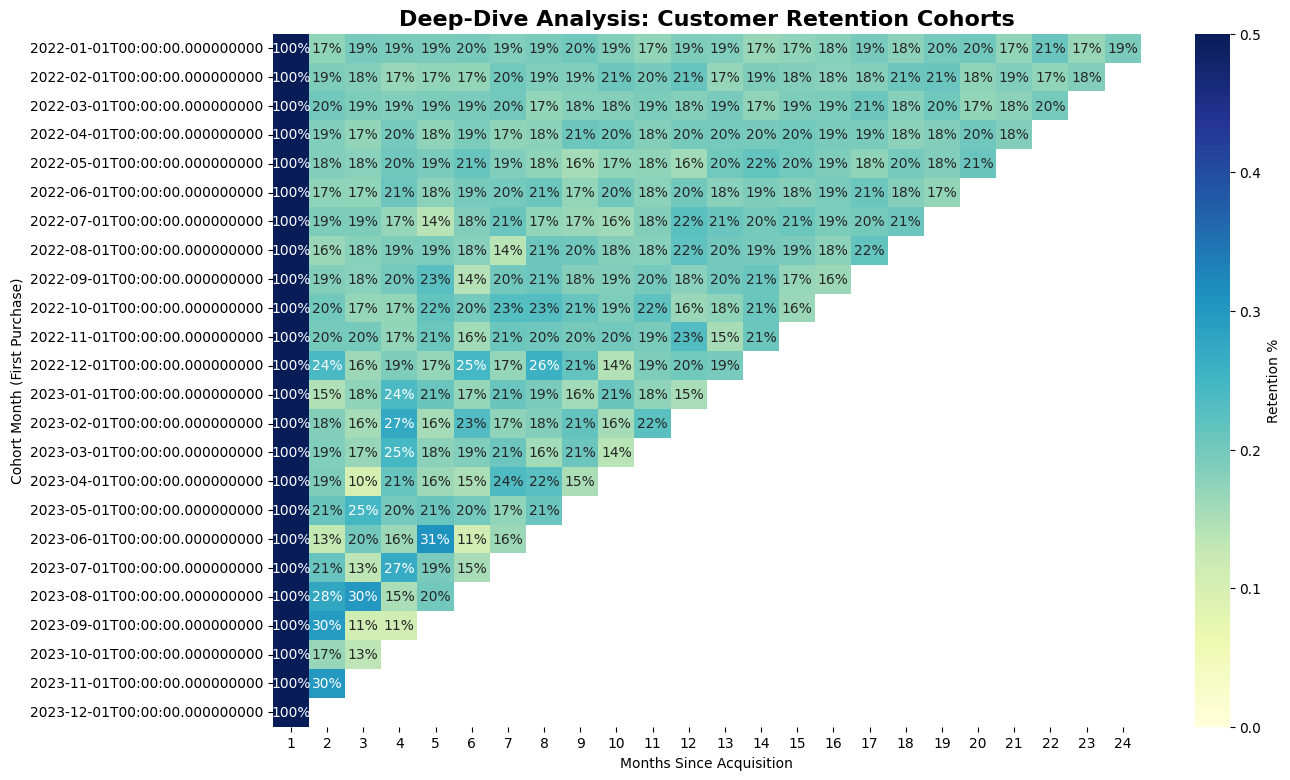

In [ ]:
# --- 5. STEP 3: INTERACTIVE VISUALIZATION ---
plt.figure(figsize=(14, 9))
plt.title('Deep-Dive Analysis: Customer Retention Cohorts', fontsize=16, fontweight='bold')

sns.heatmap(data=retention_matrix,
            annot=True,
            fmt='.0%',
            vmin=0.0,
            vmax=0.5,
            cmap='YlGnBu',
            cbar_kws={'label': 'Retention %'})

plt.ylabel('Cohort Month (First Purchase)')
plt.xlabel('Months Since Acquisition')
plt.show()